Importando as bibliotecas

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Caregando a base e verificando o tamanho do dataset junto com o Balanceamento das classes

In [17]:
iris = load_iris()

X = iris.data
y = iris.target

print("Tamanho do dataset:", X.shape)
print("\nBalanceamento das classes:")
print(pd.Series(y).value_counts())

Tamanho do dataset: (150, 4)

Balanceamento das classes:
0    50
1    50
2    50
Name: count, dtype: int64


1 - Utilizar somente o algoritmo de árvore com os hiper-parâmetros default

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Acurácia do modelo: 100.00%


2 - Utilizar k_fold aplicado na árvore, considerando 3, 5, 7 e 10 folds

In [19]:
modelo = DecisionTreeClassifier()

folds = [3,5,7,10]

print("\nResultados K-Fold:")
for k in folds:
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X, y, cv=kfold)
    print(f"K = {k}")
    print("Acurácia média:", scores.mean())


Resultados K-Fold:
K = 3
Acurácia média: 0.9466666666666667
K = 5
Acurácia média: 0.9600000000000002
K = 7
Acurácia média: 0.9526901669758813
K = 10
Acurácia média: 0.9533333333333334


3 - Utilizar gridsearch com a árvore para avaliar a melhor combinação de hiper-parâmetros.

In [20]:
parametros = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    parametros,
    cv=5,
    scoring='accuracy'
)

grid.fit(X, y)

print("\nMelhores parâmetros:")
print(grid.best_params_)
print("Melhor acurácia:", grid.best_score_)


Melhores parâmetros:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor acurácia: 0.9733333333333334


Treinar modelo com melhores dados

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo_final = grid.best_estimator_
modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

Matriz de Confusão


Matriz de Confusão:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



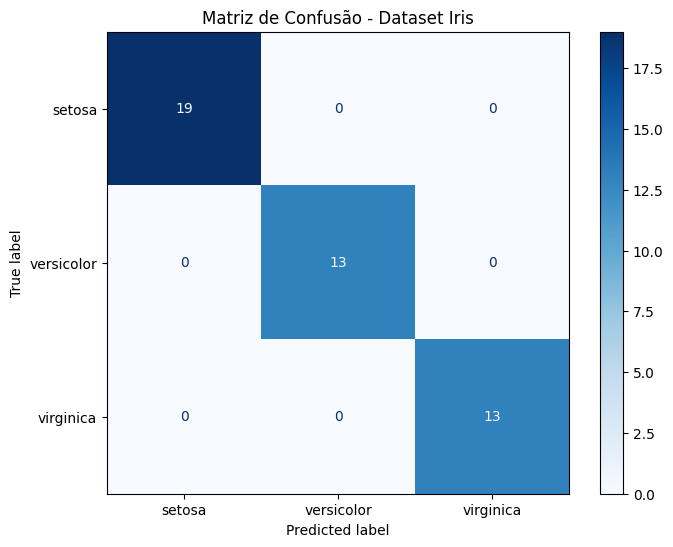

In [22]:
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(cm)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax)

plt.title("Matriz de Confusão - Dataset Iris")
plt.show()

Resultados estatísticos obtidos das analises de VP,VN,FP e FN   

In [23]:
print("\nVP, VN, FP, FN por classe:")

for i in range(len(cm)):
    VP = cm[i,i]
    FN = cm[i,:].sum() - VP
    FP = cm[:,i].sum() - VP
    VN = cm.sum() - (VP + FN + FP)

    print(f"\nClasse {i}:")
    print("VP:", VP)
    print("FN:", FN)
    print("FP:", FP)
    print("VN:", VN)


VP, VN, FP, FN por classe:

Classe 0:
VP: 19
FN: 0
FP: 0
VN: 26

Classe 1:
VP: 13
FN: 0
FP: 0
VN: 32

Classe 2:
VP: 13
FN: 0
FP: 0
VN: 32
